In [46]:
import numpy as np
import pandas as pd

In [47]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\tested.csv" , usecols=['Survived' , 'Cabin' , 'Ticket'])

In [48]:
import random

# Values to use
values = ['1', '2', 'B', '5', '6', 'A']
total_length = 418

# Repeat enough times to cover 418, then shuffle
result = []
while len(result) < total_length:
    result += values
random.shuffle(result)

# Trim to exact 418 elements
result = result[:total_length]

# Print the scrambled list
print(result)

['6', '2', '2', '6', '6', 'A', '2', 'A', '5', '1', '1', '2', '1', '5', 'A', '6', 'A', '2', 'B', '1', '6', 'A', 'B', 'A', '2', 'A', 'B', '1', '5', '5', '5', '2', '5', 'B', 'A', '1', 'B', '6', '6', '6', '5', '1', '5', '2', '1', '1', '2', '2', 'A', '1', 'A', 'A', '6', '2', 'A', '5', '5', '1', 'B', '1', '2', '6', 'B', 'B', '1', '6', '2', '1', '6', 'B', '1', '2', '1', 'A', 'B', '1', '2', 'A', '2', 'B', '1', '2', '1', '6', '5', '5', '5', '6', 'A', '1', 'B', '6', '2', '6', '5', '2', 'A', '1', '6', '5', '1', 'B', '5', '5', '2', '2', '1', '2', 'B', 'B', 'A', 'B', '6', '6', '2', '6', 'B', '1', '1', 'B', '2', '2', '6', '1', 'B', 'A', '6', '6', '6', 'B', '5', 'B', '2', 'B', '5', '2', '6', 'A', '6', '5', 'B', '2', '1', '5', '1', 'B', 'B', '5', '5', '2', 'B', 'A', '6', '5', '1', 'A', '2', '1', '5', 'B', '2', '2', '5', '2', '5', '1', '6', '2', '6', '5', '6', 'A', '6', '1', '5', '1', 'B', 'B', 'B', '1', '6', '6', '2', 'B', '2', '1', '5', '5', '1', 'B', '2', '5', 'A', '6', 'A', '2', 'B', '6', '1', '5',

In [49]:
number = pd.DataFrame(result)

In [50]:
df.join(number)

,Survived,Ticket,Cabin,0
0,0,330911,NaN,6
1,1,363272,NaN,2
2,0,240276,NaN,2
3,0,315154,NaN,6
4,1,3101298,NaN,6
...,...,...,...,...
413,0,A.5. 3236,NaN,A
414,1,PC 17758,C105,5
415,0,SOTON/O.Q. 3101262,NaN,A
416,0,359309,NaN,B


In [51]:

def clean_data(df):
    df = df.rename(columns={0: 'numbers'})
    return df

df = df.join(number)

df_clean = clean_data(df.copy())
df_clean.head()

,Survived,Ticket,Cabin,numbers
0,0,330911,NaN,6
1,1,363272,NaN,2
2,0,240276,NaN,2
3,0,315154,NaN,6
4,1,3101298,NaN,6


In [52]:
df_clean.dropna()

,Survived,Ticket,Cabin,numbers
12,1,21228,B45,1
14,1,W.E.P. 5734,E31,A
24,1,PC 17608,B57 B59 B63 B66,2
26,1,113509,B36,B
28,0,113054,A21,5
...,...,...,...,...
404,0,17765,D40,6
405,0,SC/PARIS 2166,D38,2
407,0,113503,C80,1
411,1,19928,C78,2


In [53]:
df_clean['numbers'].unique()

array(['6', '2', 'A', '5', '1', 'B'], dtype=object)

Text(0.5, 1.0, 'Passenger travelling with')

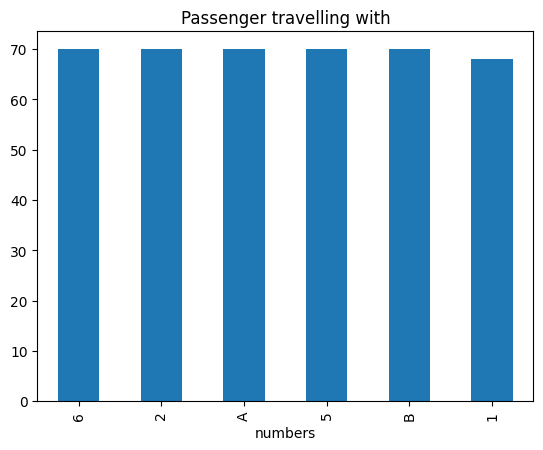

In [54]:
fig = df_clean['numbers'].value_counts().plot.bar()
fig.set_title('Passenger travelling with')

In [55]:
# extract numerical part
df_clean["numbers_numerical"] = pd.to_numeric(df_clean['numbers'] , errors='coerce' , downcast='integer')

In [56]:
#extract categorical part
df_clean["numbers_categorical"] = np.where(df_clean['numbers_numerical'].isnull(), df_clean['numbers'], np.nan)

In [59]:
df_clean.head()

,Survived,Ticket,Cabin,numbers,numbers_numerical,numbers_categorical
0,0,330911,NaN,6,6.0,NaN
1,1,363272,NaN,2,2.0,NaN
2,0,240276,NaN,2,2.0,NaN
3,0,315154,NaN,6,6.0,NaN
4,1,3101298,NaN,6,6.0,NaN


In [60]:
df_clean['Cabin'].unique()

array([nan, 'B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34',
       'D19', 'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53',
       'D43', 'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116',
       'F', 'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22',
       'B10', 'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64',
       'A11', 'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89',
       'F E46', 'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78',
       'F E57', 'F2', 'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60',
       'E50', 'E39 E41', 'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7',
       'D40', 'D38', 'C105'], dtype=object)

In [61]:
df_clean['Ticket'].unique()

array(['330911', '363272', '240276', '315154', '3101298', '7538',
       '330972', '248738', '2657', 'A/4 48871', '349220', '694', '21228',
       '24065', 'W.E.P. 5734', 'SC/PARIS 2167', '233734', '2692',
       'STON/O2. 3101270', '2696', 'PC 17603', 'C 17368', 'PC 17598',
       'PC 17597', 'PC 17608', 'A/5. 3337', '113509', '2698', '113054',
       '2662', 'SC/AH 3085', 'C.A. 31029', 'C.A. 2315', 'W./C. 6607',
       '13236', '2682', '342712', '315087', '345768', '1601', '349256',
       '113778', 'SOTON/O.Q. 3101263', '237249', '11753',
       'STON/O 2. 3101291', 'PC 17594', '370374', '11813', 'C.A. 37671',
       '13695', 'SC/PARIS 2168', '29105', '19950', 'SC/A.3 2861',
       '382652', '349230', '348122', '386525', '349232', '237216',
       '347090', '334914', 'F.C.C. 13534', '330963', '113796', '2543',
       '382653', '349211', '3101297', 'PC 17562', '113503', '359306',
       '11770', '248744', '368702', '2678', 'PC 17483', '19924', '349238',
       '240261', '2660', '3308

In [63]:
df_clean['cabin_num'] = df_clean['Cabin'].str.extract('(\d+)')
df_clean['cabin_cat'] = df_clean['Cabin'].str[0]

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Acer\AppData\Local\Temp\ipykernel_47796\888501240.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_clean['cabin_num'] = df_clean['Cabin'].str.extract('(\d+)')


In [65]:
df_clean.head(50)

,Survived,Ticket,Cabin,numbers,numbers_numerical,numbers_categorical,cabin_num,cabin_cat
0,0,330911,NaN,6,6.0,NaN,NaN,NaN
1,1,363272,NaN,2,2.0,NaN,NaN,NaN
2,0,240276,NaN,2,2.0,NaN,NaN,NaN
3,0,315154,NaN,6,6.0,NaN,NaN,NaN
4,1,3101298,NaN,6,6.0,NaN,NaN,NaN
5,0,7538,NaN,A,NaN,A,NaN,NaN
6,1,330972,NaN,2,2.0,NaN,NaN,NaN
7,0,248738,NaN,A,NaN,A,NaN,NaN
8,1,2657,NaN,5,5.0,NaN,NaN,NaN
9,0,A/4 48871,NaN,1,1.0,NaN,NaN,NaN


In [68]:
df_clean['Ticket_num'] = df_clean['Ticket'].apply(lambda x: x.split()[-1])
df_clean['Ticket_num'] = pd.to_numeric(df_clean['Ticket_num'] , errors='coerce' , downcast='integer')

df_clean['Ticket_cat'] = df_clean['Ticket'].apply(lambda x: x.split()[0])
df_clean['Ticket_cat'] = np.where(df_clean['Ticket_cat'].str.isdigit() , np.nan , df_clean['Ticket_cat'])

In [71]:
df_clean.head(50)

,Survived,Ticket,Cabin,numbers,numbers_numerical,numbers_categorical,cabin_num,cabin_cat,Ticket_num,Ticket_cat
0,0,330911,NaN,6,6.0,NaN,NaN,NaN,330911,NaN
1,1,363272,NaN,2,2.0,NaN,NaN,NaN,363272,NaN
2,0,240276,NaN,2,2.0,NaN,NaN,NaN,240276,NaN
3,0,315154,NaN,6,6.0,NaN,NaN,NaN,315154,NaN
4,1,3101298,NaN,6,6.0,NaN,NaN,NaN,3101298,NaN
5,0,7538,NaN,A,NaN,A,NaN,NaN,7538,NaN
6,1,330972,NaN,2,2.0,NaN,NaN,NaN,330972,NaN
7,0,248738,NaN,A,NaN,A,NaN,NaN,248738,NaN
8,1,2657,NaN,5,5.0,NaN,NaN,NaN,2657,NaN
9,0,A/4 48871,NaN,1,1.0,NaN,NaN,NaN,48871,A/4
